In [1]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

# Nastav working directory na kořen projektu
_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f"✓ Working directory: {os.getcwd()}")
# PFNs — musí být naklonováno (viz setup.sh)
from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

print("✓ PFNs načteny")

✓ Device: mps
✓ PyTorch: 2.10.0
✓ Working directory: /Users/ruslanguliev/VU_RG
✓ PFNs načteny


In [2]:
# =============================================
# LOAD HELPER 
# =============================================

def load_pfn_model(checkpoint_path, device='cpu'):
    """
    Načte PFN model z checkpointu. Podporuje tři formáty:

    1. Nový formát (MainConfig dict, 'priors' key):
       - Uloženo přes epoch loop v PFN_TRAIN_SETUP.ipynb nebo pfn_train*.py
       - Config obsahuje celou architekturu → nlayers, emsize atd. se čtou automaticky

    2. Starý formát ('hps' key):
       - Uloženo přes train_gp_pfn()
       - Config obsahuje jen HP, architektura se musí rekonstruovat
       - nlayers se pokusí přečíst z config; pokud chybí, vyhodí chybu

    Vrací: (model, hps, epoch)
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Model nenalezen: {checkpoint_path}\n")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config_data = checkpoint.get('config', {})

    # --- Formát 1: MainConfig dict (nový) ---
    if isinstance(config_data, dict) and 'priors' in config_data:
        saved_config = MainConfig.from_dict(config_data)
        model = saved_config.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        hps = saved_config.priors[0].prior_kwargs.get('hyperparameters', {})
        epoch = checkpoint.get('epoch', '?')

    # --- Formát 2: starý formát ('hps' key) ---
    elif isinstance(config_data, dict) and 'hps' in config_data:
        hps = config_data['hps']
        epoch = config_data.get('epochs', checkpoint.get('epoch', '?'))
        criterion = checkpoint['criterion']

        nlayers = config_data.get('nlayers')
        if nlayers is None:
            # Odvoď nlayers ze state_dict — spočítej nejvyšší index vrstvy
            layer_indices = [
                int(k.split('.')[2])
                for k in checkpoint['model_state_dict']
                if k.startswith('transformer_layers.layers.')
            ]
            nlayers = max(layer_indices) + 1 if layer_indices else 6

        emsize  = config_data.get('emsize',  512)
        nhead   = config_data.get('nhead',   8)
        nhid    = config_data.get('nhid',    1024)

        cfg = MainConfig(
            priors=[AdhocPriorConfig(
                get_batch_methods=[get_batch_for_gp],
                prior_kwargs={'num_features': 1, 'hyperparameters': hps}
            )],
            optimizer=OptimizerConfig('adamw', lr=0.0003),
            model=TransformerConfig(
                criterion=BarDistributionConfig(
                    full_support=True,
                    borders=criterion.borders.tolist()
                ),
                emsize=emsize, nhead=nhead, nhid=nhid, nlayers=nlayers,
                features_per_group=1,
                attention_between_features=False,
                encoder=EncoderConfig(
                    constant_normalization_mean=0.5,
                    constant_normalization_std=math.sqrt(1/12)
                )
            ),
            batch_shape_sampler=BatchShapeSamplerConfig(
                batch_size=64, max_seq_len=50,
                min_num_features=1, max_num_features=1
            ),
            epochs=1, warmup_epochs=0,
            steps_per_epoch=1, num_workers=0,
        )
        model = cfg.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        model.criterion = criterion

    else:
        raise ValueError(f"Neznámý formát checkpointu. Klíče config: {list(config_data.keys())}")

    model.to(device)
    model.eval()
    print(f"✓ Model načten: {os.path.basename(checkpoint_path)}")
    print(f"  Epocha: {epoch}, nlayers: {nlayers if 'nlayers' in dir() else '(z MainConfig)'}")
    print(f"  Parametrů: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")
    return model, hps, epoch

print("✓ load_pfn_model připraven")

✓ load_pfn_model připraven


In [3]:
# =============================================
# NAČTENÍ MODELU
# =============================================

# DŮLEŽITÉ: get_batch_for_gp_random_hps musí být definována PŘED torch.load,
# protože checkpoint obsahuje přímou referenci na tuto funkci v pickle datech.
def get_batch_for_gp_random_hps(batch_size, seq_len, num_features, device="cpu", hyperparameters=None, **kwargs):
    random_hps = {
        "lengthscale": float(np.random.uniform(0.05, 1.0)),
        "outputscale": float(np.random.lognormal(0, 0.5)),
        "noise":       float(10 ** np.random.uniform(-5, -2)),
    }
    return get_batch_for_gp(batch_size, seq_len, num_features, device=device, hyperparameters=random_hps, **kwargs)

checkpoint_path = os.path.join("models", "pfn_rand_hps_1layer.pth")

print(f"Loading: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

config = checkpoint["config"]

# Podpora obou formátů checkpointu:
#   Starý formát: config["num_features"], config["max_dataset_size"], checkpoint["criterion"]
#   Nový formát (MainConfig): config["priors"][...], config["batch_shape_sampler"][...], config["model"]["criterion"]["borders"]
if "num_features" in config:
    # Starý formát
    num_features     = config["num_features"]
    max_dataset_size = config["max_dataset_size"]
    criterion        = checkpoint["criterion"]
    borders          = criterion.borders.tolist()
    prior_hps        = config.get("hps", {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.3})
    get_batch_fn     = get_batch_for_gp
    prior_kwargs     = {"num_features": num_features, "hyperparameters": prior_hps}
    nlayers          = config.get("nlayers", 6)
else:
    # Nový formát (MainConfig)
    num_features     = config["priors"][0]["prior_kwargs"]["num_features"]
    max_dataset_size = config["batch_shape_sampler"]["max_seq_len"]
    borders          = config["model"]["criterion"]["borders"]
    nlayers          = config["model"].get("nlayers", 6)
    get_batch_fn     = get_batch_for_gp_random_hps
    prior_kwargs     = {"num_features": num_features, "hyperparameters": {}}
    criterion        = None  # rekonstruujeme po dummy tréninku

print(f"  nlayers z checkpointu: {nlayers}")

model_config = MainConfig(
    priors=[AdhocPriorConfig(
        get_batch_methods=[get_batch_fn],
        prior_kwargs=prior_kwargs
    )],
    optimizer=OptimizerConfig("adamw", lr=0.0003),
    model=TransformerConfig(
        criterion=BarDistributionConfig(full_support=True, borders=borders),
        emsize=512,
        nhead=8,
        nhid=1024,
        nlayers=nlayers,
        features_per_group=1,
        attention_between_features=False,
        encoder=EncoderConfig(
            constant_normalization_mean=0.5,
            constant_normalization_std=math.sqrt(1/12)
        )
    ),
    batch_shape_sampler=BatchShapeSamplerConfig(
        batch_size=2,
        max_seq_len=max_dataset_size,
        min_num_features=num_features,
        max_num_features=num_features
    ),
    epochs=1,
    steps_per_epoch=1,
    num_workers=0,
)

print("Vytvářím strukturu modelu...")
dummy_result = train(model_config, device=device, reusable_config=False)
loaded_model = dummy_result["model"]

loaded_model.load_state_dict(checkpoint["model_state_dict"])
if criterion is not None:
    loaded_model.criterion = criterion
loaded_model.to(device)
loaded_model.eval()

# =============================================
# GLOBÁLNÍ NASTAVENÍ
# =============================================
# Defaultní HP pro experimenty
hps = {"noise": 1e-3, "outputscale": 1.0, "lengthscale": 0.3}
hps_demo = hps

def reset_seed():
    import random
    s = random.randint(0, 2**32 - 1)
    torch.manual_seed(s)
    np.random.seed(s % (2**31))
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def get_batch_cpu(batch_size, seq_len, num_features, hyperparameters, device):
    """Wrapper: generuje data na CPU (správný seed), přesune na device."""
    batch = get_batch_for_gp(batch_size, seq_len, num_features,
                              device="cpu", hyperparameters=hyperparameters)
    from pfns.priors.prior import Batch
    return Batch(x=batch.x.to(device), y=batch.y.to(device), target_y=batch.target_y.to(device))

# Reset seedu HNED po dummy tréninku
reset_seed()

print(f"✓ Model načten (epocha {checkpoint['epoch']})")
print(f"  Parametrů: {sum(p.numel() for p in loaded_model.parameters()) / 1e6:.2f}M")
print(f"  Defaultní HP: {hps}")

Loading: models/pfn_rand_hps_1layer.pth
  nlayers z checkpointu: 1
Vytvářím strukturu modelu...
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=100, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperpara

/Users/ruslanguliev/VU_RG/PFNs/pfns/train.py:238: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if c.train_mixed_precision else None


-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.35s | mean loss  1.25 | lr 0.0 | data time  0.00 step time  0.33 forward time  0.13 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
✓ Model načten (epocha 100)
  Parametrů: 3.65M
  Defaultní HP: {'noise': 0.001, 'outputscale': 1.0, 'lengthscale': 0.3}


In [4]:
print(f"nlayers: {loaded_model.transformer_layers.num_layers}")
print(f"Layers: {len(loaded_model.transformer_layers.layers)}")
print()
for i, layer in enumerate(loaded_model.transformer_layers.layers):
    print(f"=== Layer {i} ===")
    for name, module in layer.named_children():
        print(f"  {name}: {type(module).__name__}")


for name, module in loaded_model.named_modules():
    if 'self_attn' in name:
        print(name, type(module).__name__)

nlayers: 1
Layers: 1

=== Layer 0 ===
  self_attn_between_items: MultiHeadAttention
  mlp: MLP
  layer_norms: ModuleList
transformer_layers.layers.0.self_attn_between_items MultiHeadAttention


# Experiment 1

EXPERIMENT: Label Mixing vs. Kernel Computation per Layer

Parametry:
  Instancí: 200
  Trénovacích bodů: 40
  Testovacích bodů: 20
  Lengthscale pro NW: 0.5
  Device: mps

  Instance 50/200
  Instance 100/200
  Instance 150/200
  Instance 200/200


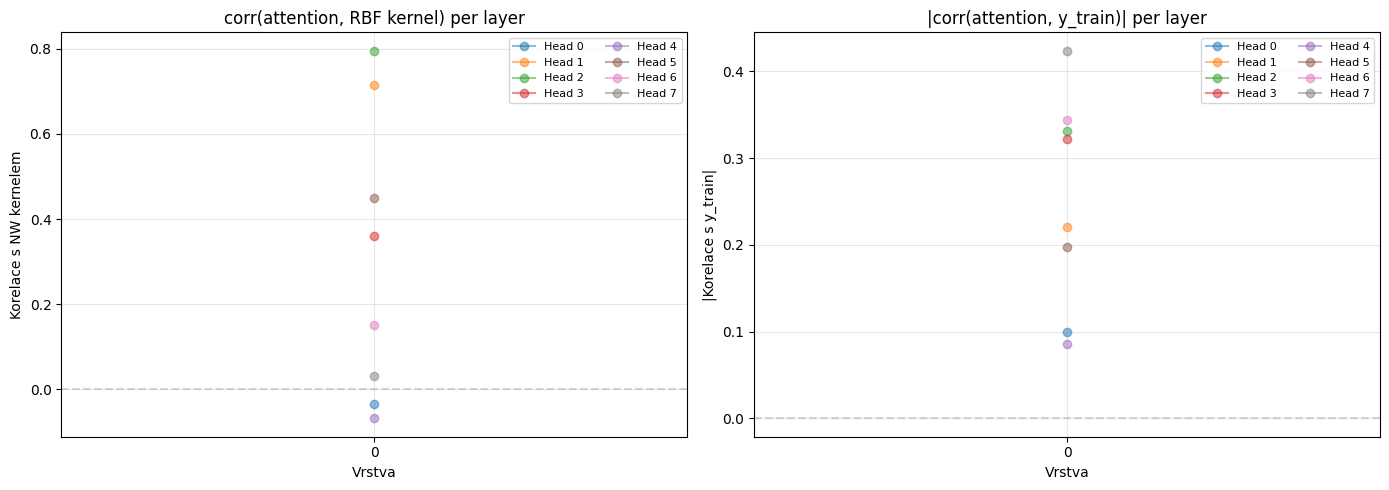

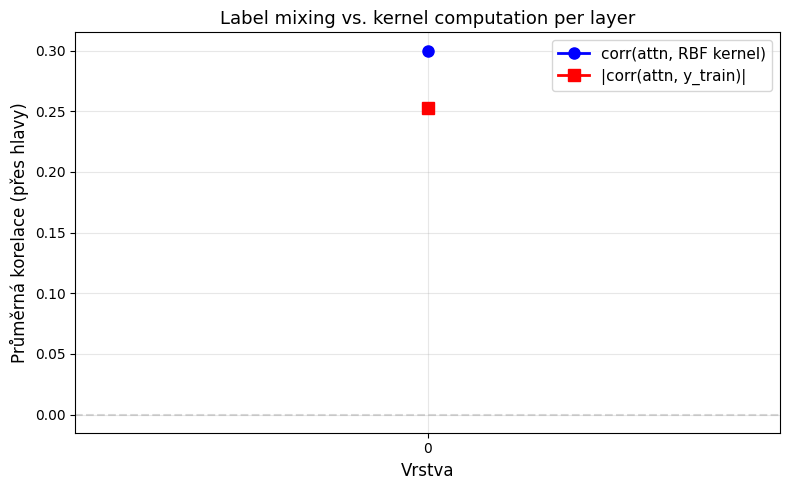


=== Průměrná korelace (přes hlavy) ===
  Vrstva |  corr(kernel) |  |corr(label)|
------------------------------------------
       0 |        0.3001 |         0.2529

=== Interpretace ===
Pokud corr(kernel) roste s hloubkou a |corr(label)| klesá:
  → Rané vrstvy mísí X a Y, pozdější se specializují na kernel
Pokud oba jsou ploché:
  → Žádná specializace, mísení je uniformní přes vrstvy


In [5]:
# =============================================
# EXPERIMENT: Label Mixing vs. Kernel Computation per Layer (Q1)
# =============================================
# Otázka: Mísí se X_j a Y_j v attention score rovnoměrně přes 
# všechny vrstvy, nebo se rané vrstvy specializují na kernel-like 
# feature comparison a pozdější na label propagation?
#
# Metrika: Pro každou vrstvu a hlavu spočítáme:
#   - corr(attention_weights, NW_kernel_weights)  ... korelace s RBF kernelem
#   - corr(attention_weights, y_train)            ... korelace s labely
#
# Pokud se vrstvy specializují:
#   - corr_kernel by měla růst s hloubkou (pozdější vrstvy → více kernel-like)
#   - corr_label by měla klesat s hloubkou
#
# PŘEDPOKLAD: Model je načtený jako `loaded_model`, device je nastavený,
#             funkce get_batch_for_gp je dostupná, hps jsou definované.
# =============================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# KROK 1: Funkce pro extrakci attention vah
# =============================================
# Používáme hooky na vstupy do self_attn_between_items,
# pak manuálně počítáme Q, K a attention váhy.
# Důvod: PFNs MultiHeadAttention nevrací attention váhy.

def extract_attention_weights(model, train_x, train_y, test_x, n_context):
    """
    Extrahuje attention váhy ze všech vrstev.
    
    Args:
        model: načtený PFN model
        train_x: (n_train, 1) trénovací souřadnice
        train_y: (n_train,) nebo (n_train, 1) trénovací hodnoty
        test_x: (n_test, 1) testovací souřadnice
        n_context: počet trénovacích bodů (= single_eval_pos)
    
    Returns:
        list of tensors, jeden per vrstva, 
        shape (1, 1, n_heads, seq_len, seq_len)
    """
    model.eval()
    layer_inputs = []
    
    def input_hook(module, inputs, output):
        layer_inputs.append(inputs[0].detach().cpu())
    
    # Najdi attention moduly a přidej hooky
    hooks = []
    attn_modules = []
    for name, module in model.named_modules():
        if 'self_attn_between_items' in name and 'self_attn_between_items.' not in name:
            hooks.append(module.register_forward_hook(input_hook))
            attn_modules.append(module)
    
    # Forward pass — DŮLEŽITÉ: test_x musí obsahovat CELOU sekvenci (train+test)
    # a train_x musí být jen trénovací část
    full_x = torch.cat([train_x, test_x], dim=0)  # (n_train + n_test, 1)
    
    with torch.no_grad():
        _ = model(
            train_x.unsqueeze(0),   # (1, n_train, 1)
            train_y.unsqueeze(0),   # (1, n_train) nebo (1, n_train, 1)
            full_x.unsqueeze(0)[:, n_context:]  # (1, n_test, 1) — jen testovací část jako test_x
        )
    
    for hook in hooks:
        hook.remove()
    
    # Manuální výpočet attention vah z hooků
    all_attention_weights = []
    for layer_idx, module in enumerate(attn_modules):
        if layer_idx >= len(layer_inputs):
            break
        
        x = layer_inputs[layer_idx]
        w_qkv = module.w_qkv.cpu()
        
        batch, features, seq_len, embed_dim = x.shape
        n_heads = w_qkv.shape[1]
        head_dim = w_qkv.shape[2]
        
        x_flat = x.reshape(-1, embed_dim)
        
        W_q = w_qkv[0]  # (heads, head_dim, embed)
        W_k = w_qkv[1]  # (heads, head_dim, embed)
        
        W_q_t = W_q.permute(2, 0, 1)  # (embed, heads, head_dim)
        W_k_t = W_k.permute(2, 0, 1)
        
        Q = torch.matmul(x_flat, W_q_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        K = torch.matmul(x_flat, W_k_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        
        Q = Q.reshape(batch, features, seq_len, n_heads, head_dim)
        K = K.reshape(batch, features, seq_len, n_heads, head_dim)
        
        Q = Q.permute(0, 1, 3, 2, 4)  # (batch, features, heads, seq, head_dim)
        K = K.permute(0, 1, 3, 2, 4)
        
        # DŮLEŽITÉ: K source je jen trénovací body (single_eval_pos)
        # Tohle je implementace toho, že model dává K,V jen z tréninku
        K_train = K[:, :, :, :n_context, :]
        
        scores = torch.matmul(Q, K_train.transpose(-2, -1)) / (head_dim ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)
        
        all_attention_weights.append(attn_weights)
    
    return all_attention_weights


# =============================================
# KROK 2: Funkce pro NW kernel váhy
# =============================================

def compute_nw_weights(x_test_val, x_train_np, lengthscale):
    """
    Spočítá Nadaraya-Watson váhy pro jeden testovací bod.
    
    Args:
        x_test_val: skalár, souřadnice testovacího bodu
        x_train_np: (n_train,) souřadnice trénovacích bodů
        lengthscale: délková škála RBF kernelu
    
    Returns:
        (n_train,) normalizované NW váhy
    """
    dists_sq = (x_test_val - x_train_np) ** 2
    kernel_vals = np.exp(-dists_sq / (2 * lengthscale ** 2))
    return kernel_vals / kernel_vals.sum()


# =============================================
# KROK 3: Hlavní experiment
# =============================================

def run_label_mixing_experiment(model, hps, n_instances=200, n_context=20, 
                                 n_test=30, lengthscale=0.3, device='cpu'):
    """
    Pro každou vrstvu a hlavu spočítá průměrnou korelaci 
    attention vah s NW kernelem a s y-hodnotami.
    
    Args:
        model: načtený PFN model
        hps: hyperparametry pro generování GP dat
        n_instances: počet testovacích instancí k průměrování
        n_context: počet trénovacích bodů
        n_test: počet testovacích bodů
        lengthscale: délková škála pro NW srovnání
        device: 'cpu', 'cuda', nebo 'mps'
    
    Returns:
        corr_kernel: (n_layers, n_heads) průměrná korelace s RBF kernelem
        corr_label: (n_layers, n_heads) průměrná korelace s y_train
    """
    model.eval()
    model.to(device)
    
    n_layers = len([m for n, m in model.named_modules() 
                    if 'self_attn_between_items' in n and '.' not in n.split('self_attn_between_items')[-1]])
    n_heads = model.nhead
    
    # Akumulátory
    corr_kernel_sum = np.zeros((n_layers, n_heads))
    corr_label_sum = np.zeros((n_layers, n_heads))
    valid_counts = np.zeros((n_layers, n_heads))
    
    seq_len = n_context + n_test
    
    for instance in range(n_instances):
        if (instance + 1) % 50 == 0:
            print(f"  Instance {instance + 1}/{n_instances}")
        
        # Generuj data
        batch = get_batch_for_gp(
            batch_size=1, 
            seq_len=seq_len, 
            num_features=1, 
            hyperparameters=hps
        )
        
        train_x = batch.x[0, :n_context].to(device)    # (n_context, 1)
        train_y = batch.y[0, :n_context].to(device)     # (n_context,) nebo (n_context, 1)
        test_x = batch.x[0, n_context:].to(device)      # (n_test, 1)
        
        # Numpy verze pro korelace
        train_x_np = train_x.cpu().numpy().reshape(-1)
        train_y_np = train_y.cpu().numpy().reshape(-1)
        test_x_np = test_x.cpu().numpy().reshape(-1)
        
        # Extrahuj attention váhy
        try:
            attn_weights_all = extract_attention_weights(
                model, train_x, train_y, test_x, n_context
            )
        except Exception as e:
            print(f"  Chyba v instanci {instance}: {e}")
            continue
        
        # Pro každý testovací bod spočítej korelace
        for test_idx_local in range(n_test):
            test_idx_global = n_context + test_idx_local  # pozice v celé sekvenci
            x_star = test_x_np[test_idx_local]
            
            # NW kernel váhy
            nw_weights = compute_nw_weights(x_star, train_x_np, lengthscale)
            
            for layer_idx in range(min(len(attn_weights_all), n_layers)):
                attn = attn_weights_all[layer_idx]
                # attn shape: (1, 1, n_heads, seq_len, n_context)
                # Řádek test_idx_global = váhy testovacího bodu přes trénovací body
                
                for head_idx in range(n_heads):
                    a = attn[0, 0, head_idx, test_idx_global, :n_context].detach().cpu().numpy()
                    
                    # Kontrola, že máme validní data
                    if np.std(a) < 1e-10 or np.std(nw_weights) < 1e-10:
                        continue
                    
                    # Korelace s RBF kernelem
                    corr_k = np.corrcoef(a, nw_weights)[0, 1]
                    if not np.isnan(corr_k):
                        corr_kernel_sum[layer_idx, head_idx] += corr_k
                        valid_counts[layer_idx, head_idx] += 1
                    
                    # Korelace s y-hodnotami
                    if np.std(train_y_np) > 1e-10:
                        corr_y = np.corrcoef(a, train_y_np)[0, 1]
                        if not np.isnan(corr_y):
                            corr_label_sum[layer_idx, head_idx] += corr_y
    
    # Průměruj
    corr_kernel = corr_kernel_sum / np.maximum(valid_counts, 1)
    corr_label = corr_label_sum / np.maximum(valid_counts, 1)
    
    return corr_kernel, corr_label


# =============================================
# KROK 4: Vizualizace
# =============================================

def plot_label_mixing(corr_kernel, corr_label):
    """
    Vykreslí korelace jako funkci vrstvy, separátně pro každou hlavu.
    """
    n_layers, n_heads = corr_kernel.shape
    layers = np.arange(n_layers)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Korelace s kernelem
    ax = axes[0]
    for head in range(n_heads):
        ax.plot(layers, corr_kernel[:, head], 'o-', alpha=0.5, label=f'Head {head}')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Vrstva')
    ax.set_ylabel('Korelace s NW kernelem')
    ax.set_title('corr(attention, RBF kernel) per layer')
    ax.set_xticks(layers)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    
    # Korelace s labely
    ax = axes[1]
    for head in range(n_heads):
        ax.plot(layers, np.abs(corr_label[:, head]), 'o-', alpha=0.5, label=f'Head {head}')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Vrstva')
    ax.set_ylabel('|Korelace s y_train|')
    ax.set_title('|corr(attention, y_train)| per layer')
    ax.set_xticks(layers)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('label_mixing_per_layer.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Průměr přes hlavy
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(layers, corr_kernel.mean(axis=1), 'o-', color='blue', linewidth=2, 
            markersize=8, label='corr(attn, RBF kernel)')
    ax.plot(layers, np.abs(corr_label).mean(axis=1), 's-', color='red', linewidth=2, 
            markersize=8, label='|corr(attn, y_train)|')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_xlabel('Vrstva', fontsize=12)
    ax.set_ylabel('Průměrná korelace (přes hlavy)', fontsize=12)
    ax.set_title('Label mixing vs. kernel computation per layer', fontsize=13)
    ax.set_xticks(layers)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('label_mixing_average.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Tabulka
    print("\n=== Průměrná korelace (přes hlavy) ===")
    print(f"{'Vrstva':>8} | {'corr(kernel)':>13} | {'|corr(label)|':>14}")
    print("-" * 42)
    for l in range(n_layers):
        print(f"{l:>8} | {corr_kernel[l].mean():>13.4f} | {np.abs(corr_label[l]).mean():>14.4f}")


# =============================================
# KROK 5: Spuštění
# =============================================

print("=" * 60)
print("EXPERIMENT: Label Mixing vs. Kernel Computation per Layer")
print("=" * 60)

# Parametry experimentu
N_INSTANCES = 200   # počet testovacích instancí
N_CONTEXT = 40      # trénovací body
N_TEST = 20         # testovací body
LENGTHSCALE = 0.5   # lengthscale pro NW srovnání

print(f"\nParametry:")
print(f"  Instancí: {N_INSTANCES}")
print(f"  Trénovacích bodů: {N_CONTEXT}")
print(f"  Testovacích bodů: {N_TEST}")
print(f"  Lengthscale pro NW: {LENGTHSCALE}")
print(f"  Device: {device}")
print()

corr_kernel, corr_label = run_label_mixing_experiment(
    loaded_model, hps,
    n_instances=N_INSTANCES,
    n_context=N_CONTEXT,
    n_test=N_TEST,
    lengthscale=LENGTHSCALE,
    device=device
)

plot_label_mixing(corr_kernel, corr_label)

print("\n=== Interpretace ===")
print("Pokud corr(kernel) roste s hloubkou a |corr(label)| klesá:")
print("  → Rané vrstvy mísí X a Y, pozdější se specializují na kernel")
print("Pokud oba jsou ploché:")
print("  → Žádná specializace, mísení je uniformní přes vrstvy")